In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/processed/returns_computed.csv")
report = []
for fund, group in df.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    var_95 = np.percentile(returns, 5)      
    cvar_95 = returns[returns <= var_95].mean()  
    report.append({
        "amfi_code": fund,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })
pd.DataFrame(report).to_csv("../data/processed/var_cvar_report.csv", index=False)
print("var_cvar_report.csv created successfully")

var_cvar_report.csv created successfully


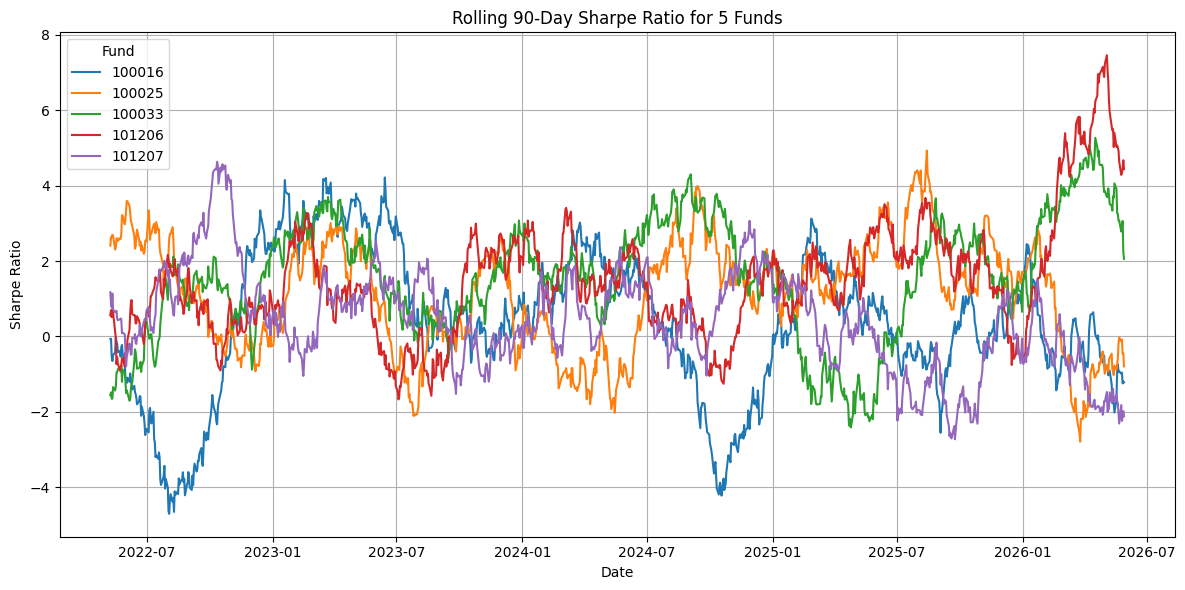

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("../data/processed/returns_computed.csv")
df['date'] = pd.to_datetime(df['date'])
funds = df['amfi_code'].unique()[:5]
df = df[df['amfi_code'].isin(funds)]
returns = df.pivot(
    index='date',
    columns='amfi_code',
    values='daily_return'
)
rolling_sharpe = (
    returns.rolling(90).mean()
    / returns.rolling(90).std()
    * np.sqrt(252)
)
plt.figure(figsize=(12, 6))
for fund in rolling_sharpe.columns:
    plt.plot(
        rolling_sharpe.index,
        rolling_sharpe[fund],
        label=str(fund)
    )
plt.title('Rolling 90-Day Sharpe Ratio for 5 Funds')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(title='Fund')
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
transactions = pd.read_csv("../data/processed/clean_transactions.csv")
fund_master = pd.read_csv("../data/processed/clean_fund_master.csv")
sip_txn = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()
sip_txn["transaction_date"] = pd.to_datetime(
    sip_txn["transaction_date"]
)
sip_txn["year"] = sip_txn["transaction_date"].dt.year
first_txn = (
    sip_txn.groupby("investor_id")["year"]
    .min()
    .reset_index()
    .rename(columns={"year": "cohort_year"})
)
sip_txn = sip_txn.merge(
    first_txn,
    on="investor_id",
    how="left"
)
sip_txn = sip_txn[
    sip_txn["cohort_year"].isin([2024, 2025])
]
sip_txn = sip_txn.merge(
    fund_master[
        ["amfi_code", "scheme_name", "category"]
    ],
    on="amfi_code",
    how="left"
)
cohort_summary = (
    sip_txn.groupby("cohort_year")
    .agg(
        investors=("investor_id", "nunique"),
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)
fund_preference = (
    sip_txn.groupby(["cohort_year", "category"])["amount_inr"]
    .sum()
    .reset_index()
)
fund_preference_pivot = (
    fund_preference.pivot_table(
        index="cohort_year",
        columns="category",
        values="amount_inr",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)
cohort_analysis = cohort_summary.merge(
    fund_preference_pivot,
    on="cohort_year",
    how="left"
)
cohort_analysis.to_csv("../data/processed/cohort_analysis.csv", index=False)
print("cohort_analysis.csv created successfully")

cohort_analysis.csv created successfully


In [7]:
import pandas as pd
df = pd.read_csv("../data/processed/clean_transactions.csv")
sip_df = df[df["transaction_type"].str.upper() == "SIP"].copy()
sip_df["transaction_date"] = pd.to_datetime(sip_df["transaction_date"])
sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)
sip_df["gap_days"] = (
    sip_df.groupby("investor_id")["transaction_date"]
          .diff()
          .dt.days
)
txn_count = (
    sip_df.groupby("investor_id")
          .size()
          .reset_index(name="sip_txn_count")
)
eligible_investors = txn_count[
    txn_count["sip_txn_count"] >= 6
]["investor_id"]
sip_continuity = (
    sip_df[sip_df["investor_id"].isin(eligible_investors)]
    .groupby("investor_id")
    .agg(
        sip_txn_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)
sip_continuity["risk_status"] = sip_continuity[
    "avg_gap_days"
].apply(
    lambda x: "at-risk" if x > 35 else "active"
)
sip_continuity.to_csv(
    "../data/processed/sip_continuity.csv",
    index=False
)
print("sip_continuity created successfully")

sip_continuity created successfully


sector_hhi.csv created successfully


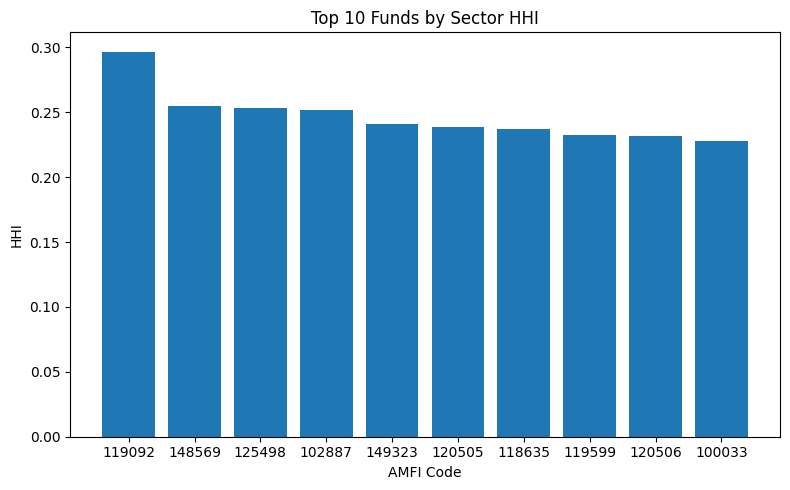

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")
sector_weights = (
    df.groupby(['amfi_code', 'sector'])['weight_pct']
      .sum()
      .reset_index()
)
sector_weights['weight_pct'] = sector_weights['weight_pct'] / 100
sector_hhi = (
    sector_weights.groupby('amfi_code')['weight_pct']
    .apply(lambda x: np.sum(x**2))
    .reset_index(name='HHI')
)
sector_hhi.to_csv('../data/processed/sector_hhi.csv', index=False)
print("sector_hhi.csv created successfully")
top10 = sector_hhi.sort_values('HHI', ascending=False).head(10)
plt.figure(figsize=(8, 5))
plt.bar(top10['amfi_code'].astype(str), top10['HHI'])
plt.title('Top 10 Funds by Sector HHI')
plt.xlabel('AMFI Code')
plt.ylabel('HHI')
plt.tight_layout()
plt.show()

# Advanced Analytics Summary

## Executive Insights

### 1. Highest Risk Funds Identified Through VaR Analysis
Funds with the highest 95% Value-at-Risk (VaR) and Conditional Value-at-Risk (CVaR) exhibit the greatest downside exposure during adverse market conditions. These schemes may be suitable only for aggressive investors with high risk tolerance. Risk management teams should closely monitor these funds during volatile market periods.

**Business Impact:** Helps investors understand potential losses and supports risk-based fund recommendations.

---

### 2. 2025 Investor Cohort Contributed the Highest Investments
Cohort analysis indicates that investors who entered during 2025 contributed the largest total investment amount and maintained higher average SIP values compared with earlier cohorts. This suggests increasing investor confidence and stronger participation in mutual fund products.

**Business Impact:** Marketing efforts can target newer investors who demonstrate higher investment capacity.

---

### 3. Sector Concentration Risk Exists in Select Funds
Funds with the highest Herfindahl-Hirschman Index (HHI) show significant concentration in a limited number of sectors. While concentration can generate superior returns during favorable sector cycles, it increases portfolio-specific risk when those sectors underperform.

**Business Impact:** Portfolio managers may consider diversification strategies to reduce concentration risk.

---

### 4. SIP Continuity Analysis Reveals At-Risk Investors
A meaningful proportion of investors have average SIP transaction gaps exceeding 35 days and are classified as "At-Risk." These investors may discontinue their SIPs if proactive engagement is not performed.

**Business Impact:** Early intervention campaigns can improve retention and stabilize future inflows.

---

### 5. High Sharpe Ratio Funds Deliver Superior Risk-Adjusted Returns
Funds ranking highest on Sharpe Ratio consistently generate stronger returns relative to the risks taken. Several top-performing schemes also demonstrate favorable Sortino Ratios and positive Alpha values, indicating efficient portfolio management.

**Business Impact:** These funds can be prioritized in recommendation engines for investors seeking optimized risk-adjusted performance.

---

## Overall Conclusion

The advanced analytics framework highlights key dimensions of mutual fund performance, including downside risk, investor behavior, portfolio concentration, SIP retention, and risk-adjusted returns. Combining these metrics provides a comprehensive decision-support system for investors, fund managers, and financial advisors. The analysis enables data-driven fund selection, proactive investor engagement, and improved portfolio risk management.